In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import re
import os
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

In [2]:
df_resolved = pd.read_pickle("../data/processed/df_resolved.pkl")
df_train    = pd.read_pickle("../data/processed/df_train.pkl")
df_test     = pd.read_pickle("../data/processed/df_test.pkl")

print(f"df_resolved: {df_resolved.shape}")
print(f"df_train:    {df_train.shape}")
print(f"df_test:     {df_test.shape}")

# Confirm desc column
print(f"\ndesc present:      {('desc' in df_resolved.columns)}")
print(f"desc non-null:     {df_resolved['desc'].notna().sum():,}")
print(f"desc coverage:     {df_resolved['desc'].notna().mean()*100:.2f}%")

df_resolved: (1348099, 154)
df_train:    (829355, 68)
df_test:     (518744, 68)

desc present:      True
desc non-null:     125,953
desc coverage:     9.34%


In [4]:
# Overall coverage
total    = len(df_resolved)
has_desc = df_resolved["desc"].notna().sum()
no_desc  = total - has_desc

print("=" * 50)
print("DESC COVERAGE SUMMARY")
print("=" * 50)
print(f"Total loans:        {total:>10,}")
print(f"Has description:    {has_desc:>10,}  ({has_desc/total*100:.1f}%)")
print(f"No description:     {no_desc:>10,}  ({no_desc/total*100:.1f}%)")

# Coverage by grade — FIXED: .size() counts ALL loans, not just non-null
print("\nCoverage by grade:")
grade_cov = df_resolved.groupby("grade").agg(
    total    = ("desc", "size"),                       # ← was .count()
    has_desc = ("desc", lambda x: x.notna().sum()),
).reset_index()
grade_cov["coverage_pct"] = (grade_cov["has_desc"] / grade_cov["total"] * 100).round(2)
print(grade_cov.to_string(index=False))

# Coverage by default status — FIXED same way
print("\nCoverage by default status:")
def_cov = df_resolved.groupby("default_flag").agg(
    total    = ("desc", "size"),                       # ← was .count()
    has_desc = ("desc", lambda x: x.notna().sum()),
).reset_index()
def_cov["coverage_pct"] = (def_cov["has_desc"] / def_cov["total"] * 100).round(2)
print(def_cov.to_string(index=False))

DESC COVERAGE SUMMARY
Total loans:         1,348,099
Has description:       125,953  (9.3%)
No description:      1,222,146  (90.7%)

Coverage by grade:
grade  total  has_desc  coverage_pct
    A 235193     24401       10.3700
    B 393102     42118       10.7100
    C 382323     30123        7.8800
    D 201657     16999        8.4300
    E  94192      7846        8.3300
    F  32306      3471       10.7400
    G   9326       995       10.6700

Coverage by default status:
 default_flag   total  has_desc  coverage_pct
            0 1078739    106344        9.8600
            1  269360     19609        7.2800


In [6]:
import re

def clean_desc(text):
    if not isinstance(text, str):
        return None
    
    # Lowercase
    text = text.lower()
    
    # Remove Lending Club boilerplate (common template phrases)
    boilerplate = [
        r"borrower added on \d{2}/\d{2}/\d{2,4}\s*>",
        r"borrower added on \d{2}/\d{2}/\d{2,4}",
        r"<br\s*/?>",
        r"&amp;",
        r"&nbsp;",
    ]
    for pattern in boilerplate:
        text = re.sub(pattern, " ", text)
    
    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    
    # Remove special characters, keep letters, numbers, spaces
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    
    # Collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    # Return None if nothing meaningful left (< 3 words)
    if len(text.split()) < 3:
        return None
    
    return text

# Apply to desc column
df_resolved["desc_clean"] = df_resolved["desc"].apply(clean_desc)

# Sanity check
total_desc        = df_resolved["desc"].notna().sum()
after_clean       = df_resolved["desc_clean"].notna().sum()
dropped           = total_desc - after_clean

print("=" * 50)
print("TEXT CLEANING SUMMARY")
print("=" * 50)
print(f"Descriptions before cleaning:  {total_desc:>8,}")
print(f"Descriptions after cleaning:   {after_clean:>8,}")
print(f"Dropped (too short after clean): {dropped:>6,}  ({dropped/total_desc*100:.1f}%)")

# Preview 5 before/after examples
print("\nSAMPLE BEFORE / AFTER:")
sample = df_resolved[df_resolved["desc"].notna()].sample(5, random_state=42)[["desc", "desc_clean"]]
for i, row in sample.iterrows():
    print(f"\nBEFORE: {row['desc'][:200]}")
    print(f"AFTER:  {row['desc_clean'][:200]}")

TEXT CLEANING SUMMARY
Descriptions before cleaning:   125,953
Descriptions after cleaning:    120,134
Dropped (too short after clean):  5,819  (4.6%)

SAMPLE BEFORE / AFTER:

BEFORE:   Borrower added on 08/12/12 > To pay off two higher interest credit cards. I am not behind in payments and have not been using the cards, I just want a lower rate and to know they are paid off and th
AFTER:  to pay off two higher interest credit cards i am not behind in payments and have not been using the cards i just want a lower rate and to know they are paid off and the new payment will be complete in

BEFORE:   Borrower added on 01/05/11 > Need to pay off some of my mortgage so that I can refinance at a much lower rate.<br/> Borrower added on 01/05/11 > I've been an industrial electrician over thirty years
AFTER:  need to pay off some of my mortgage so that i can refinance at a much lower rate i ve been an industrial electrician over thirty years my pay has always been very stable with much overtime 

In [8]:
print("desc_clean" in df_resolved.columns)
print("desc_word_count" in df_resolved.columns)

True
True


In [10]:
wc = df_resolved["desc_word_count"].dropna()
print(type(wc), len(wc))

<class 'pandas.Series'> 120134


DESCRIPTION LENGTH SUMMARY
Mean words:    39.5
Median words:  26.0
Std dev:       49.7
Min:           3
Max:           795
90th pct:      80
95th pct:      119

Mean word count by default flag:
default_flag
0   39.6000
1   39.4000


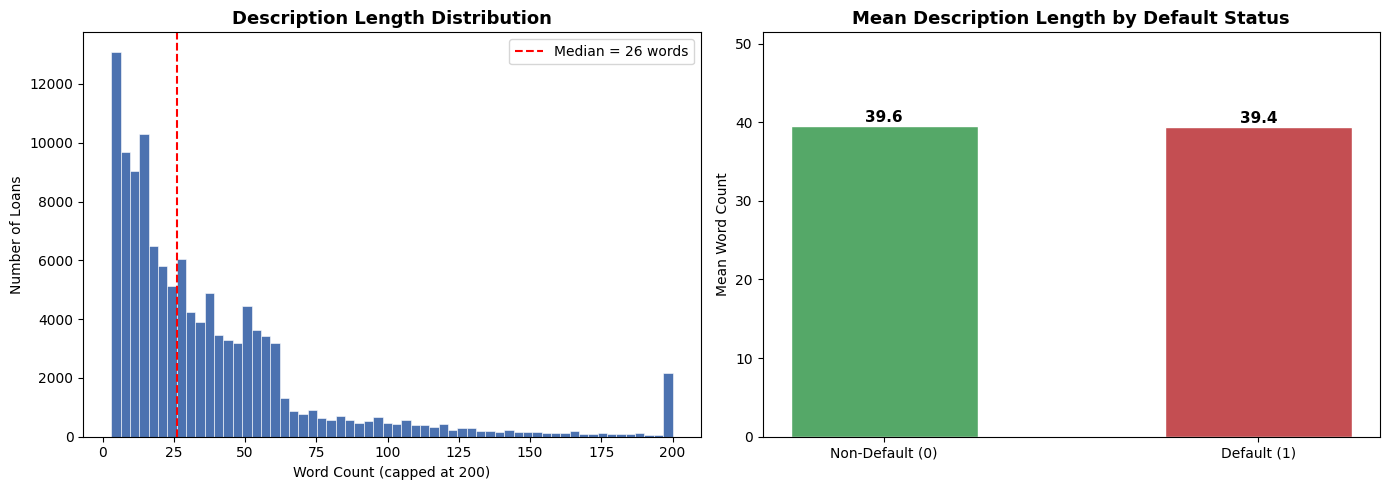

Saved → outputs/desc_length_distribution.png


In [13]:
# Compute word count for all cleaned descriptions
df_resolved["desc_word_count"] = df_resolved["desc_clean"].apply(
    lambda x: len(x.split()) if isinstance(x, str) else None
)

# Summary stats
print("=" * 50)
print("DESCRIPTION LENGTH SUMMARY")
print("=" * 50)
print(f"Mean words:    {wc.mean():.1f}")
print(f"Median words:  {wc.median():.1f}")
print(f"Std dev:       {wc.std():.1f}")
print(f"Min:           {wc.min():.0f}")
print(f"Max:           {wc.max():.0f}")
print(f"90th pct:      {wc.quantile(0.90):.0f}")
print(f"95th pct:      {wc.quantile(0.95):.0f}")

# Mean word count by default decile
# Bin loans with desc into PD deciles using loan_status as proxy
desc_df = df_resolved[df_resolved["desc_word_count"].notna()].copy()

print("\nMean word count by default flag:")
print(desc_df.groupby("default_flag")["desc_word_count"]
      .mean().round(1).to_string())

# Plot 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Overall length distribution (cap at 200 words for readability)
axes[0].hist(
    wc.clip(upper=200), bins=60,
    color="#4C72B0", edgecolor="white", linewidth=0.4
)
axes[0].axvline(wc.median(), color="red", linestyle="--", linewidth=1.5,
                label=f"Median = {wc.median():.0f} words")
axes[0].set_title("Description Length Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Word Count (capped at 200)")
axes[0].set_ylabel("Number of Loans")
axes[0].legend()

# Plot 2: Mean word count by default flag
mean_wc = desc_df.groupby("default_flag")["desc_word_count"].mean()
bars = axes[1].bar(
    ["Non-Default (0)", "Default (1)"],
    mean_wc.values,
    color=["#55A868", "#C44E52"],
    width=0.5, edgecolor="white"
)
axes[1].set_title("Mean Description Length by Default Status", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Mean Word Count")
axes[1].set_ylim(0, mean_wc.max() * 1.3)
for bar, val in zip(bars, mean_wc.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5, f"{val:.1f}",
                 ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/desc_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/desc_length_distribution.png")

Training rows with descriptions: 120,122
Default rate in this subset:     15.5%


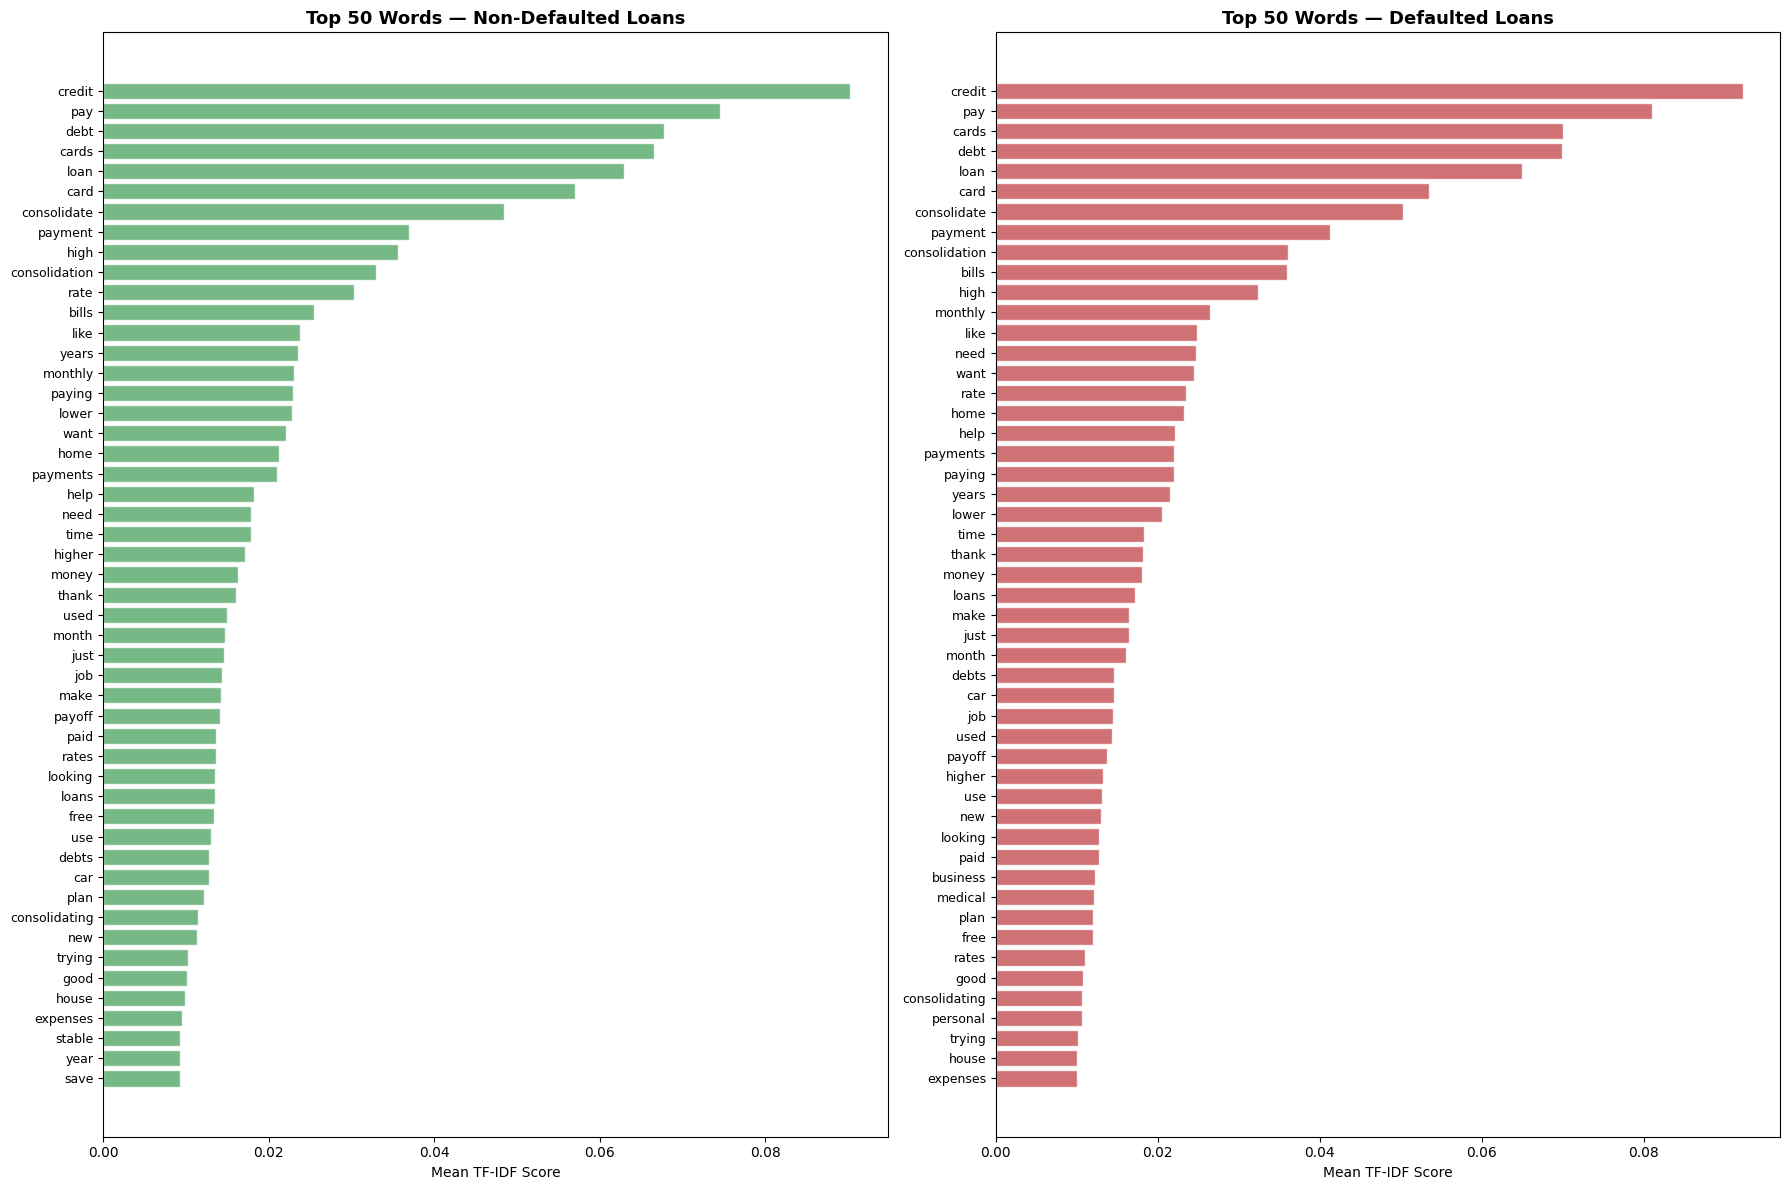

Saved → outputs/tfidf_top50_words.png

TOP 20 — NON-DEFAULT:
  credit                    0.0902
  pay                       0.0745
  debt                      0.0677
  cards                     0.0666
  loan                      0.0629
  card                      0.0570
  consolidate               0.0484
  payment                   0.0369
  high                      0.0356
  consolidation             0.0329
  rate                      0.0303
  bills                     0.0255
  like                      0.0238
  years                     0.0236
  monthly                   0.0230
  paying                    0.0229
  lower                     0.0228
  want                      0.0220
  home                      0.0212
  payments                  0.0210

TOP 20 — DEFAULT:
  credit                    0.0922
  pay                       0.0810
  cards                     0.0700
  debt                      0.0699
  loan                      0.0650
  card                      0.0534
  consolid

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import numpy as np

# Work only on training set rows that have clean descriptions
train_desc = df_train[df_train.index.isin(
    df_resolved[df_resolved["desc_clean"].notna()].index
)].copy()

# Merge desc_clean back onto train set
train_desc = train_desc.join(df_resolved[["desc_clean"]], how="inner")
train_desc = train_desc[train_desc["desc_clean"].notna()]

print(f"Training rows with descriptions: {len(train_desc):,}")
print(f"Default rate in this subset:     {train_desc['default_flag'].mean()*100:.1f}%")

# Split by default status
default_texts     = train_desc[train_desc["default_flag"] == 1]["desc_clean"].tolist()
non_default_texts = train_desc[train_desc["default_flag"] == 0]["desc_clean"].tolist()

# Fit TF-IDF on each group separately to get group-specific top terms
def get_top_tfidf_terms(texts, n=50):
    vec = TfidfVectorizer(
        max_features=5000,
        stop_words="english",
        ngram_range=(1, 1),
        min_df=10
    )
    tfidf_matrix = vec.fit_transform(texts)
    mean_scores   = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
    terms         = vec.get_feature_names_out()
    top_idx       = mean_scores.argsort()[::-1][:n]
    return [(terms[i], mean_scores[i]) for i in top_idx]

top_default     = get_top_tfidf_terms(default_texts)
top_non_default = get_top_tfidf_terms(non_default_texts)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 12))

for ax, top_terms, title, color in zip(
    axes,
    [top_non_default, top_default],
    ["Top 50 Words — Non-Defaulted Loans", "Top 50 Words — Defaulted Loans"],
    ["#55A868", "#C44E52"]
):
    words  = [t[0] for t in top_terms]
    scores = [t[1] for t in top_terms]
    y_pos  = range(len(words))

    ax.barh(list(y_pos), scores, color=color, alpha=0.8, edgecolor="white")
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Mean TF-IDF Score")

plt.tight_layout()
plt.savefig("../outputs/tfidf_top50_words.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/tfidf_top50_words.png")

# Print top 20 from each for reference
print("\nTOP 20 — NON-DEFAULT:")
for word, score in top_non_default[:20]:
    print(f"  {word:<25} {score:.4f}")

print("\nTOP 20 — DEFAULT:")
for word, score in top_default[:20]:
    print(f"  {word:<25} {score:.4f}")

Train: 96,107  |  default rate: 15.5%
Test:  24,027   |  default rate: 15.5%

TF-IDF LOGISTIC REGRESSION — TEST SET RESULTS
AUROC:  0.5931
Gini:   0.1862
KS:     0.1398


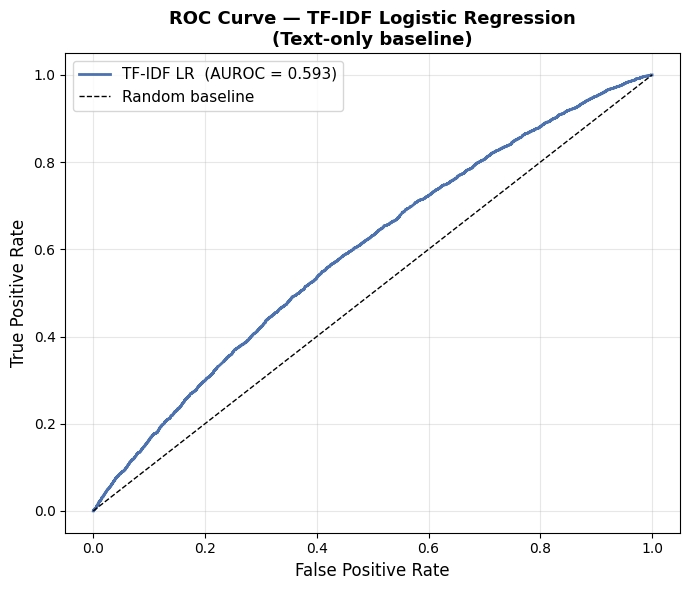

Saved → outputs/tfidf_lr_roc_curve.png

Saved → outputs/tfidf_baseline_results.csv
                                 model  auroc   gini     ks  n_train  n_test
TF-IDF Logistic Regression (text only) 0.5931 0.1862 0.1398    96107   24027


In [ ]:
# NOTE: TF-IDF model uses stratified random split within description-having subset
# because Lending Club discontinued the desc field before the temporal test period.
# This model is therefore not directly comparable to the WoE/XGBoost models.

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# Fresh stratified split within description-having subset only
desc_df = df_resolved[df_resolved["desc_clean"].notna()].copy()

X_train_text, X_test_text, y_train, y_test = train_test_split(
    desc_df["desc_clean"],
    desc_df["default_flag"],
    test_size=0.2,
    random_state=42,
    stratify=desc_df["default_flag"]
)

print(f"Train: {len(X_train_text):,}  |  default rate: {y_train.mean()*100:.1f}%")
print(f"Test:  {len(X_test_text):,}   |  default rate: {y_test.mean()*100:.1f}%")

# Fit TF-IDF vectorizer on train only
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=10,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

# Train logistic regression
lr_text = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver="lbfgs",
    random_state=42,
    n_jobs=-1
)
lr_text.fit(X_train_tfidf, y_train)

# ── Evaluate on test set ───────────────────────────────────
y_pred_proba = lr_text.predict_proba(X_test_tfidf)[:, 1]

# AUROC
auroc = roc_auc_score(y_test, y_pred_proba)

# Gini
gini = 2 * auroc - 1

# KS statistic
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
ks = (tpr - fpr).max()

print("\n" + "=" * 50)
print("TF-IDF LOGISTIC REGRESSION — TEST SET RESULTS")
print("=" * 50)
print(f"AUROC:  {auroc:.4f}")
print(f"Gini:   {gini:.4f}")
print(f"KS:     {ks:.4f}")

# ── ROC curve plot ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="#4C72B0", linewidth=2,
        label=f"TF-IDF LR  (AUROC = {auroc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random baseline")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — TF-IDF Logistic Regression\n(Text-only baseline)", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/tfidf_lr_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/tfidf_lr_roc_curve.png")

# ── Save results for later comparison ─────────────────────
import pandas as pd
tfidf_results = pd.DataFrame([{
    "model":   "TF-IDF Logistic Regression (text only)",
    "auroc":   round(auroc, 4),
    "gini":    round(gini, 4),
    "ks":      round(ks, 4),
    "n_train": len(X_train_text),   
    "n_test":  len(X_test_text),    
}])
tfidf_results.to_csv("../outputs/tfidf_baseline_results.csv", index=False)
print("\nSaved → outputs/tfidf_baseline_results.csv")
print(tfidf_results.to_string(index=False))

In [16]:
print("df_resolved index type:", df_resolved.index.dtype)
print("df_train index type:   ", df_train.index.dtype)
print("df_test index type:    ", df_test.index.dtype)

print("\ndf_resolved index sample:", df_resolved.index[:5].tolist())
print("df_train index sample:   ", df_train.index[:5].tolist())
print("df_test index sample:    ", df_test.index[:5].tolist())

df_resolved index type: int64
df_train index type:    int64
df_test index type:     int64

df_resolved index sample: [0, 1, 2, 4, 5]
df_train index sample:    [0, 1, 2, 4, 5]
df_test index sample:     [421101, 421113, 421120, 421135, 421137]


## Notebook 07 — Text EDA: Results Summary

---

### Dataset
| | |
|---|---|
| Total loans | 1,348,099 |
| Loans with description | 120,134 (9.3%) |
| Description period | Training window only — Lending Club discontinued `desc` field before temporal test period |

---

### Coverage Analysis
| Dimension | Finding |
|---|---|
| Coverage by grade | 7.88% – 10.74% — uniform across A–G, no selection bias |
| Coverage by default status | Non-default 9.86% vs Default 7.28% |
| Interpretation | Mild underrepresentation of defaulters in description-having subset. Known limitation — carried forward to downstream models |

---

### Text Cleaning
| | |
|---|---|
| Dropped after cleaning | 5,819 (4.6%) |
| Reason | Pure boilerplate with no borrower content after stripping Lending Club template text |

---

### Description Length
| Metric | Value |
|---|---|
| Median word count | 26 words |
| Mean word count | 39.5 words |
| Non-default mean | 39.6 |
| Default mean | 39.4 |
| **Key finding** | **Length carries no predictive signal — difference is 0.2 words. Signal must reside in content, not volume.** |

---

### TF-IDF Word Analysis
| Group | Notable words (vs other group) |
|---|---|
| Defaulters | `need` (rank 14 vs 23), `help` (rank 18 vs 22), `bills` (rank 10 vs 13), `medical` (rank 42 vs absent) |
| Non-defaulters | `lower` (rank 17 vs 26), `stable` (rank 47 vs absent), `save` (rank 50 vs absent) |
| **Key finding** | **Top 6 words identical across both groups. Subtle distress vs aspiration language gap motivates structured LLM extraction over raw TF-IDF.** |

---

### TF-IDF Logistic Regression Baseline
| | |
|---|---|
| Split | Stratified random 80/20 within description-having subset only |
| Train | 96,107 loans — default rate 15.5% |
| Test | 24,027 loans — default rate 15.5% |
| **AUROC** | **0.5931** |
| **Gini** | **0.1862** |
| **KS** | **0.1398** |
| Interpretation | Text carries real but modest signal. Meaningful lift above random (0.50), well below structured WoE/XGBoost (~0.70+). Gap motivates LLM extraction in NB08. |

---

### Next Notebook
**Notebook 08 — LLM Extraction:** Use Ollama to extract five structured signals from borrower descriptions — `financial_distress_flag`, `purpose_clarity`, `income_stability_mention`, `repayment_confidence`, `overall_sentiment` — and test whether structured signals outperform raw TF-IDF.